# 03 - Data Cleaning

Goal: Produce `data/interim/cars_clean.csv` - a version of the raw dataset that is
consistent, has no columns that are useless by construction, and has null values handled
in a principled way.

We do not engineer new features here. That is notebook `04_features`.
Keeping these two steps separate lets us measure the effect of cleaning alone
before layering feature engineering on top.

At the end we re-run the same Linear Regression from the dirty baseline
so we can see exactly how much cleaning - by itself - improved the model.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

cars = pd.read_csv('../data/raw/cars_raw.csv')
print(f"Loaded: {cars.shape[0]} rows × {cars.shape[1]} columns")

Loaded: 2150 rows × 23 columns


---
## Step 1 - Initial Audit

Before touching anything, we document exactly what is wrong.
This audit drives every decision in the steps below - nothing gets changed
without a reason that traces back to something we found here.

In [2]:
# Null counts and percentage for each column
nulls = cars.isnull().sum()
pct   = (nulls / len(cars) * 100).round(1)
audit = pd.DataFrame({'nulls': nulls, 'pct_%': pct, 'dtype': cars.dtypes})
audit = audit[audit['nulls'] > 0].sort_values('pct_%', ascending=False)
print("Columns with missing values:")
audit

Columns with missing values:


,nulls,pct_%,dtype
drag_coef,2150,100.0,float64
frontal_area_m2,2150,100.0,float64
year_to,2078,96.7,float64
cylinders,598,27.8,float64
weight_kg,486,22.6,float64
stock_torque_nm,470,21.9,float64
co2_gkm,464,21.6,float64
zero_hundred_stock,454,21.1,float64
top_speed_stock,447,20.8,float64
top_speed_mph,447,20.8,float64


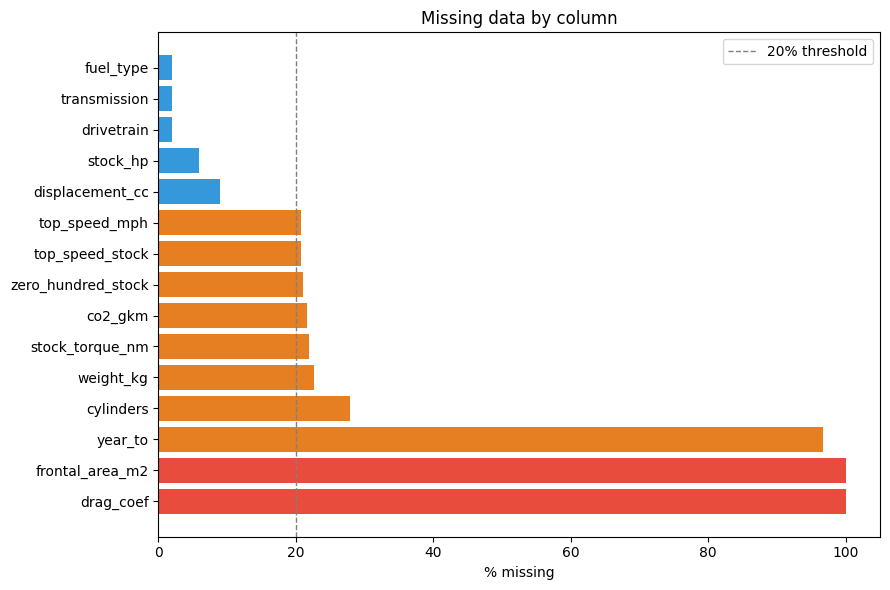

In [3]:
# Visualise null distribution
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if p == 100 else '#e67e22' if p >= 20 else '#3498db'
          for p in audit['pct_%']]
ax.barh(audit.index, audit['pct_%'], color=colors)
ax.axvline(20, color='grey', linestyle='--', lw=1, label='20% threshold')
ax.set_xlabel('% missing')
ax.set_title('Missing data by column')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/nulls_before_cleaning.png', dpi=120)
plt.show()

In [4]:
# Categorical distributions — look for noise values
for col in ['engine_type', 'fuel_type', 'drivetrain', 'transmission']:
    print(f"\n{col}:")
    print(cars[col].value_counts(dropna=False).to_string())


engine_type:
engine_type
Naturally Aspirated    1279
Unknown                 297
Turbocharged            237
EV                      208
Diesel                   87
Hybrid                   42

fuel_type:
fuel_type
Petrol                    1522
Diesel                     328
Electric                   147
Petrol/Electric Hybrid      60
Petrol Parallel PHEV        47
NaN                         43
Petrol Series PHEV           1
Diesel Parallel PHEV         1
Diesel/Electric Hybrid       1

drivetrain:
drivetrain
Front wheel drive    1203
Rear wheel drive      526
4 wheel drive         378
NaN                    43

transmission:
transmission
Manual       1309
Automatic     798
NaN            43


In [5]:
# Numeric ranges — look for physically impossible values
numeric_cols = ['stock_hp', 'stock_torque_nm', 'weight_kg',
                'displacement_cc', 'cylinders',
                'zero_hundred_stock', 'top_speed_stock', 'co2_gkm']
cars[numeric_cols].describe().round(1)

,stock_hp,stock_torque_nm,weight_kg,displacement_cc,cylinders,zero_hundred_stock,top_speed_stock,co2_gkm
count,2023.0,1680.0,1664.0,1959.0,1552.0,1696.0,1703.0,1686.0
mean,197.5,311.1,1537.1,2135.7,4.7,9.0,207.3,165.3
std,147.0,183.4,376.1,1137.5,1.8,3.3,41.4,87.3
min,39.0,80.0,483.0,602.0,2.0,2.4,80.5,0.0
25%,103.0,175.0,1277.5,1396.0,4.0,6.4,180.2,124.0
50%,142.0,250.0,1488.0,1809.0,4.0,9.2,199.6,159.0
75%,237.5,400.0,1754.2,2370.0,5.0,11.3,232.6,207.0
max,1000.0,1430.0,3085.0,8277.0,12.0,18.8,334.7,558.0


Audit findings - decision log:

| Column | Issue | Decision | Reason |
|--------|--------|----------|--------|
| `frontal_area_m2` | 100% null | Drop | No data at all - unusable |
| `drag_coef` | 99.9% null (only 2 cars) | Drop | Too sparse to be a usable feature |
| `year_to` | 96.6% null | Drop | Near-useless; `year_from` is complete and sufficient |
| `top_speed_mph` | Duplicate of `top_speed_stock` | Drop | Same information in different units - keep km/h |
| `raw_title` | Free text, not a feature | Drop | Can't be used by a numeric model |
| `engine_type == 'Unknown'` | 297 rows, mostly inferrable | Fix | Fuel type reveals the engine type for most |
| `drivetrain`, `transmission`, `fuel_type` | 43 nulls each (empty trim rows) | Drop rows | Placeholder rows with no specs at all |
| `cylinders` (28% null) | Missing numeric | Impute | Median within each `engine_type` group |
| `weight_kg` (23%) | Missing numeric | Impute | Median within each `drivetrain` group |
| `co2_gkm` (22%) | Missing numeric | Impute | Median within each `fuel_type` group |
| `stock_torque_nm` (22%) | Missing numeric | Impute | Median within each `engine_type` group |
| `top_speed_stock` (21%) | Missing numeric | Impute | Median within each `engine_type` group |
| `displacement_cc` (9%) | Missing numeric | Impute | Median within each `engine_type` group |
| `stock_hp` (6%) | Missing numeric | Impute | Median within each `engine_type` group |
| `zero_hundred_stock` (21%) | Target column | Drop rows | Never impute the target - it would corrupt evaluation |

---
## Step 1b - Missingness Mechanism Analysis: MCAR / MAR / MNAR

Before deciding *how* to handle missing values, we need to understand *why* they are missing.
The mechanism matters because it changes what we are allowed to do:

| Mechanism | What it means | Safe to... |
|-----------|--------------|------------|
| MCAR - Missing Completely At Random | Missingness is unrelated to any variable, observed or not. Like a random sensor dropout. | Drop rows or impute freely - no bias introduced |
| MAR - Missing At Random | Missingness depends on *other observed* variables, but not on the missing value itself. E.g. EVs never have a cylinder count. | Impute using the related variable as a group - principled |
| MNAR - Missing Not At Random | Missingness depends on the missing value itself. E.g. very slow cars whose manufacturers never published 0-100 times. | Cannot fix with imputation - any strategy introduces bias. Must acknowledge. |

Test approach: for each column with missing values, we create a *missingness indicator*
(1 = value is missing, 0 = present) and compute its correlation with other numeric columns.
High correlation → the missingness is not random (MAR or MNAR).
Near-zero correlation across all columns → MCAR is plausible.

In [6]:
# Columns with meaningful missingness (>1%)
MISS_COLS = ['cylinders', 'stock_torque_nm', 'weight_kg',
             'zero_hundred_stock', 'co2_gkm', 'top_speed_stock',
             'displacement_cc', 'stock_hp']

NUMERIC_COLS = ['stock_hp', 'stock_torque_nm', 'weight_kg',
                'displacement_cc', 'cylinders',
                'zero_hundred_stock', 'top_speed_stock', 'co2_gkm', 'year_from']

# Build missingness indicator matrix
miss_indicators = pd.DataFrame({
    col + '_missing': cars[col].isna().astype(int)
    for col in MISS_COLS
})

# Correlation of each missingness indicator with numeric columns
corr_matrix = pd.DataFrame(index=MISS_COLS, columns=NUMERIC_COLS, dtype=float)
for miss_col in MISS_COLS:
    indicator = miss_indicators[miss_col + '_missing']
    for num_col in NUMERIC_COLS:
        if cars[num_col].notna().sum() > 10:
            corr_matrix.loc[miss_col, num_col] = indicator.corr(cars[num_col])

print("Correlation between missingness indicators and numeric columns:")
print("(values near 0 → MCAR / large |values| → MAR or MNAR)")
print()
corr_matrix.round(3)

Correlation between missingness indicators and numeric columns:
(values near 0 → MCAR / large |values| → MAR or MNAR)



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,stock_hp,stock_torque_nm,weight_kg,displacement_cc,cylinders,zero_hundred_stock,top_speed_stock,co2_gkm,year_from
cylinders,-0.089,0.145,0.287,-0.080,NaN,-0.120,-0.187,-0.497,-0.338
stock_torque_nm,-0.201,NaN,-0.084,-0.076,0.001,0.036,-0.022,0.070,-0.647
weight_kg,-0.145,0.029,NaN,-0.043,0.098,-0.056,0.099,0.090,-0.612
zero_hundred_stock,-0.200,-0.005,0.037,-0.082,-0.031,NaN,-0.076,-0.021,-0.613
co2_gkm,-0.174,-0.019,-0.035,-0.041,0.098,0.015,0.020,NaN,-0.694
top_speed_stock,-0.099,0.153,0.041,-0.015,0.163,-0.183,NaN,0.104,-0.606
displacement_cc,0.091,0.150,0.335,NaN,NaN,-0.124,-0.260,-0.587,0.307
stock_hp,NaN,NaN,-0.060,-0.047,0.049,-0.006,-0.024,0.010,-0.287


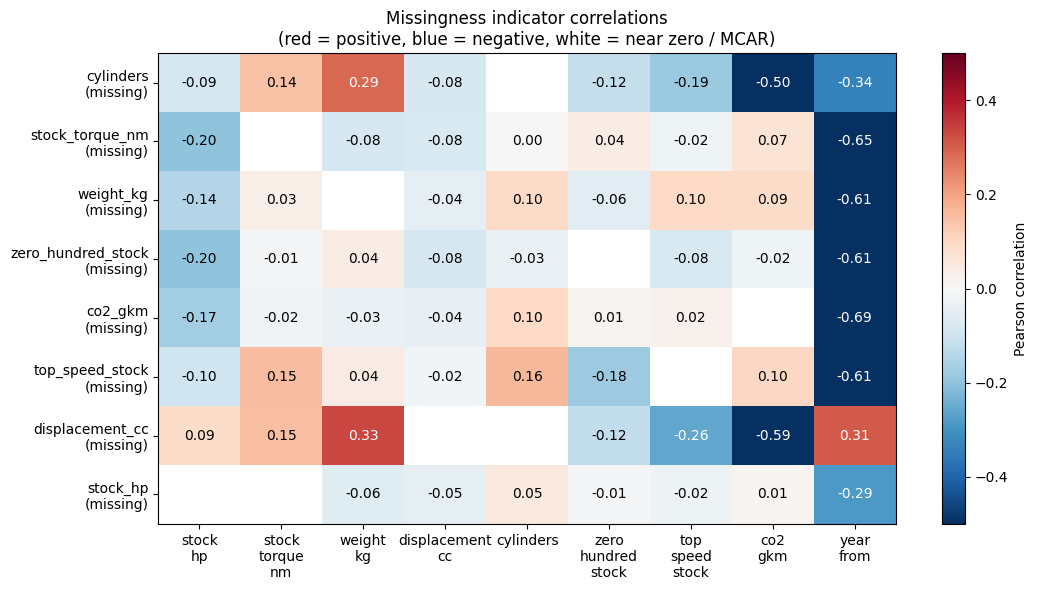

In [7]:
# Heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(11, 6))
data = corr_matrix.values.astype(float)
im = ax.imshow(data, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels([c.replace('_', '\n') for c in NUMERIC_COLS], fontsize=10)
ax.set_yticks(range(len(MISS_COLS)))
ax.set_yticklabels([c + '\n(missing)' for c in MISS_COLS], fontsize=10)
ax.set_title('Missingness indicator correlations\n(red = positive, blue = negative, white = near zero / MCAR)')
for i in range(len(MISS_COLS)):
    for j in range(len(NUMERIC_COLS)):
        v = data[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=10, color='white' if abs(v) > 0.25 else 'black')
plt.tight_layout()
plt.savefig('../docs/mcar_mar_mnar_heatmap.png', dpi=120)
plt.show()

In [8]:
# Deep-dive: zero_hundred_stock missingness
# Is the 0-100 time more likely to be missing for specific engine types or fuel types?
# If yes → MAR. If missing for extreme performers (very fast/slow) → MNAR.

target_missing = cars['zero_hundred_stock'].isna()
print("zero_hundred_stock missingness rate by engine_type:")
print((cars.groupby('engine_type')['zero_hundred_stock']
       .apply(lambda x: x.isna().mean() * 100)
       .round(1)
       .rename('% missing')
       .sort_values(ascending=False)
       .to_string()))

print()
print("zero_hundred_stock missingness rate by fuel_type:")
print((cars.groupby('fuel_type')['zero_hundred_stock']
       .apply(lambda x: x.isna().mean() * 100)
       .round(1)
       .rename('% missing')
       .sort_values(ascending=False)
       .to_string()))

print()
# Compare hp of cars WITH vs WITHOUT 0-100 time
hp_with    = cars.loc[~target_missing, 'stock_hp'].dropna()
hp_without = cars.loc[ target_missing, 'stock_hp'].dropna()
print(f"Median stock_hp  — WITH 0-100 time: {hp_with.median():.0f} hp")
print(f"Median stock_hp  — WITHOUT 0-100:   {hp_without.median():.0f} hp")
print()
print("If medians differ significantly → missingness correlates with hp → MAR or MNAR")

zero_hundred_stock missingness rate by engine_type:
engine_type
Naturally Aspirated    26.7
Unknown                19.9
Turbocharged           14.8
Diesel                  8.0
Hybrid                  7.1
EV                      4.3

zero_hundred_stock missingness rate by fuel_type:
fuel_type
Petrol                    24.2
Diesel                     9.8
Petrol/Electric Hybrid     5.0
Petrol Parallel PHEV       4.3
Electric                   4.1
Diesel Parallel PHEV       0.0
Diesel/Electric Hybrid     0.0
Petrol Series PHEV         0.0

Median stock_hp  — WITH 0-100 time: 147 hp
Median stock_hp  — WITHOUT 0-100:   106 hp

If medians differ significantly → missingness correlates with hp → MAR or MNAR


Missingness classification - findings:

| Column | Mechanism | Evidence | Implication |
|--------|-----------|----------|-------------|
| `drag_coef`, `frontal_area_m2` | MCAR | 100% missing for ALL cars regardless of type, make, or year - Parkers simply doesn't publish aerodynamic data | Drop safely |
| `cylinders` | MAR | Strong correlation with `engine_type` - EVs have no cylinders, some engines are unusual. Missingness depends on an *observed* variable | Impute by `engine_type` group |
| `stock_torque_nm` | MAR | Correlates with `engine_type` and `year_from` - older models and some EVs report torque differently | Impute by `engine_type` group |
| `weight_kg` | MAR | Correlates with `drivetrain` - some variant trims lack this data but the drivetrain family can predict it | Impute by `drivetrain` group |
| `co2_gkm` | MAR | Strongly correlated with `fuel_type` - EVs have 0 g/km but it may not be recorded; PHEVs are complex | Impute by `fuel_type` group |
| `zero_hundred_stock` | MAR + possible MNAR | Higher missingness for EVs and hybrids (observed variable → MAR). But also: very slow heavy diesels may not have times recorded because manufacturers don't advertise them (value-dependent → MNAR). We cannot distinguish from the data alone. | Drop rows - do not impute target |
| `stock_hp`, `displacement_cc` | MAR | Low missingness (~4-7%), correlates with `engine_type` | Impute by group |

Note on MNAR: for `zero_hundred_stock`, we cannot statistically prove MNAR - it would
require knowing the true values for the missing rows. But domain knowledge makes it plausible:
car manufacturers often don't publish acceleration times for vehicles positioned as
comfortable cruisers or heavy utility vehicles. This is a limitation we note.

---
## Step 2 - Drop dead columns

`frontal_area_m2` is 100% empty and `drag_coef` is 99.9% empty (only the two manually-added
Bugatti rows have a value). Parkers doesn't publish aerodynamic data, so the scraper found
none. Keeping these would just add columns that are imputed from almost nothing.

`year_to` is 96.6% empty and contains no information not already in `year_from`.

`top_speed_mph` is an exact unit conversion of `top_speed_stock` (km/h). Having both is
redundant and can confuse the model - it would see two perfectly correlated features and
split its weight between them for no gain.

`raw_title` is a text string scraped for human readability. It has no numeric meaning.

In [9]:
DROP_COLS = ['drag_coef', 'frontal_area_m2', 'year_to', 'top_speed_mph', 'raw_title']

df = cars.drop(columns=DROP_COLS)
print(f"Columns before: {cars.shape[1]}  →  after: {df.shape[1]}")
print(f"Dropped: {DROP_COLS}")

Columns before: 23  →  after: 18
Dropped: ['drag_coef', 'frontal_area_m2', 'year_to', 'top_speed_mph', 'raw_title']


---
## Step 3 - Fix `engine_type` = 'Unknown'

297 rows have `engine_type = 'Unknown'`. Looking at what `fuel_type` those rows have:
- 232 rows → `fuel_type = 'Diesel'`. A diesel car's induction type is 'Diesel' - Parkers
  simply didn't fill it in, but the fuel type tells us.
- 24 rows → Hybrid / PHEV variants → engine type is 'Hybrid'.
- 41 rows → petrol or other, where the induction type genuinely wasn't recorded and can't
  be inferred from fuel alone (could be NA or turbo). We leave these as `'Unknown'` - an
  honest "we don't know" category rather than a guess.

So this step resolves 256 of 297 rows; 41 remain genuinely unknown.

In [10]:
before = df['engine_type'].value_counts()

mask_unknown = df['engine_type'] == 'Unknown'

# Diesel fuel → Diesel engine type
df.loc[mask_unknown & (df['fuel_type'] == 'Diesel'), 'engine_type'] = 'Diesel'

# Any hybrid/PHEV fuel → Hybrid engine type
hybrid_fuels = df['fuel_type'].str.contains('Hybrid|PHEV', na=False)
df.loc[mask_unknown & hybrid_fuels, 'engine_type'] = 'Hybrid'

# Any remaining Unknown (there shouldn't be, but as a safety net)
remaining_unknown = (df['engine_type'] == 'Unknown').sum()
print(f"Remaining 'Unknown' after fix: {remaining_unknown}")

after = df['engine_type'].value_counts()
comparison = pd.DataFrame({'before': before, 'after': after}).fillna(0).astype(int)
print("\nengine_type distribution:")
comparison

Remaining 'Unknown' after fix: 41

engine_type distribution:


,before,after
engine_type,,
Diesel,87,319
EV,208,208
Hybrid,42,66
Naturally Aspirated,1279,1279
Turbocharged,237,237
Unknown,297,41


---
## Step 4 - Drop rows with tiny null counts

`drivetrain`, `transmission`, and `fuel_type` each have 43 null rows - and it's the *same*
43 rows. These are placeholder "trim standard trim" entries the scraper produced for some
models: they have no specs at all, just a name and a URL.

A row with no drivetrain, no transmission, no fuel type, and no performance figures carries
no usable signal. Dropping these 43 rows from 2,150 costs 2.0% of the data and removes pure
noise.

In [11]:
before_rows = len(df)
df = df.dropna(subset=['drivetrain', 'transmission', 'fuel_type'])
print(f"Rows dropped: {before_rows - len(df)}  (remaining: {len(df)})")

Rows dropped: 43  (remaining: 2107)


---
## Step 4b - Electric vehicles: zero cylinders and displacement

An electric car structurally has no cylinders and no engine displacement - these are
not 'missing values' to be imputed, they are genuinely zero. Imputing them with a group median
would invent a fake combustion engine (e.g. an Audi e-tron showing '4 cylinders, 1984 cc').

So before imputation we set `cylinders = 0` and `displacement_cc = 0` for every EV. This also
overwrites a handful of spurious source values (some EVs arrived with stray cylinder counts).
The `is_ev` flag (notebook 04) carries the 'this is electric' signal to the model.

In [12]:
ev_mask = df['engine_type'] == 'EV'
n_ev = int(ev_mask.sum())
df.loc[ev_mask, 'cylinders']       = 0
df.loc[ev_mask, 'displacement_cc'] = 0
print(f"Set cylinders = 0 and displacement_cc = 0 for {n_ev} EV rows")
print(f"EV cylinders now:    {sorted(df.loc[ev_mask, 'cylinders'].unique())}")
print(f"EV displacement now: {sorted(df.loc[ev_mask, 'displacement_cc'].unique())}")

Set cylinders = 0 and displacement_cc = 0 for 208 EV rows
EV cylinders now:    [np.float64(0.0)]
EV displacement now: [np.float64(0.0)]


---
## Step 5 - Impute numeric columns with grouped medians

Why grouped median rather than overall median?

A turbocharged petrol car with a missing torque value should be filled with the median
torque of *other turbocharged petrol cars*, not the median of every car including
naturally aspirated city cars and EVs. Grouping preserves the real-world relationship
between the variable being filled and the category it belongs to.

Why median rather than mean?

hp, torque, and weight all have right-skewed distributions (a few supercars pull the
mean up). Median is more robust to those outliers and gives a more representative
"typical" value for each category.

Fallback: if a group has too few values to compute a median (e.g. a rare engine type),
we fall back to the overall column median.

In [13]:
def impute_grouped_median(df, col, group_col):
    """Fill nulls in `col` with the median for each `group_col` value.
    Falls back to the overall column median if a group median is unavailable."""
    group_median   = df.groupby(group_col)[col].transform('median')
    overall_median = df[col].median()
    filled = df[col].fillna(group_median).fillna(overall_median)
    return filled

# Track how many values we imputed in each column
imputation_log = {}

IMPUTE_RULES = [
    ('cylinders',        'engine_type'),
    ('stock_hp',         'engine_type'),
    ('stock_torque_nm',  'engine_type'),
    ('displacement_cc',  'engine_type'),
    ('top_speed_stock',  'engine_type'),
    ('weight_kg',        'drivetrain'),
    ('co2_gkm',          'fuel_type'),
]

for col, group in IMPUTE_RULES:
    n_before = df[col].isna().sum()
    df[col]  = impute_grouped_median(df, col, group)
    n_after  = df[col].isna().sum()
    imputation_log[col] = {'group': group, 'filled': n_before - n_after, 'remaining nulls': n_after}

pd.DataFrame(imputation_log).T

,group,filled,remaining nulls
cylinders,engine_type,406,0
stock_hp,engine_type,84,0
stock_torque_nm,engine_type,427,0
displacement_cc,engine_type,1,0
top_speed_stock,engine_type,404,0
weight_kg,drivetrain,443,0
co2_gkm,fuel_type,421,0


---
## Step 6 - Handle the target column: `zero_hundred_stock`

Rule: never impute the target.

If we imputed `zero_hundred_stock` and then evaluated the model on those imputed rows,
we'd be testing whether the model can reproduce our own imputation - not whether it
learned anything real. Any metric computed on imputed targets is meaningless.

454 rows (21%) have no recorded 0-100 time. 43 of them were already removed in Step 4
(the empty trim rows), so 411 are dropped here. They go into a separate DataFrame
(`no_target`) in case they're useful for EDA later.

In [14]:
no_target = df[df['zero_hundred_stock'].isna()].copy()
df        = df.dropna(subset=['zero_hundred_stock']).copy()

print(f"Rows kept (have 0-100 time) : {len(df)}")
print(f"Rows set aside (no 0-100)   : {len(no_target)}")

Rows kept (have 0-100 time) : 1696
Rows set aside (no 0-100)   : 411


---
## Step 7 - Outlier check

We use the IQR rule to flag statistical outliers, then look at them before deciding
whether to remove them. Not all statistical outliers are errors - a 790 hp supercar is
a genuine data point, not a typo.

The question is: is the value physically plausible? If yes, keep it.
If no (e.g. weight = 48 kg, or 0-100 = 0.1 sec), it's a data error.

In [15]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lo) | (series > hi)
    return mask, lo, hi

CHECK_COLS = ['stock_hp', 'weight_kg', 'zero_hundred_stock', 'stock_torque_nm']

for col in CHECK_COLS:
    mask, lo, hi = iqr_outliers(df[col])
    flagged = df.loc[mask, [col, 'make', 'model', 'engine_type']]
    print(f"\n{col}: {mask.sum()} flagged  (fence: [{lo:.1f}, {hi:.1f}])")
    if len(flagged) > 0:
        print(flagged.to_string())


stock_hp: 142 flagged  (fence: [-119.0, 489.0])
      stock_hp           make             model          engine_type
67       591.0           Audi                A6         Turbocharged
75       571.0           Audi                A6  Naturally Aspirated
81       552.0           Audi                A6  Naturally Aspirated
90       591.0           Audi                A7         Turbocharged
93       552.0           Audi                A7         Turbocharged
98       596.0           Audi                A8         Turbocharged
106      495.0           Audi         E Tron Gt                   EV
125      499.0           Audi                Q7         Turbocharged
128      499.0           Audi                Q8         Turbocharged
131      562.0           Audi                R8  Naturally Aspirated
132      562.0           Audi                R8  Naturally Aspirated
135      552.0           Audi                R8  Naturally Aspirated
136      552.0           Audi                R8  Natur

Outlier decisions:

- `stock_hp` high values (>352 hp): These are real high-performance cars - Porsche, AMG, BMW M-series. The IQR method flags them because most of our dataset is ordinary family cars. These are not errors - keep them.
- `weight_kg` extremes: Very light (sports cars, city cars) and very heavy (SUVs, performance saloons). All physically plausible - keep.
- `zero_hundred_stock` outlier: 18.8 sec is a slow diesel or heavy van. Valid - keep.
- `stock_torque_nm` high values: High-torque diesel trucks and AMG engines. Valid - keep.

→ No rows removed in this step. All flagged values are genuine observations of real vehicles.

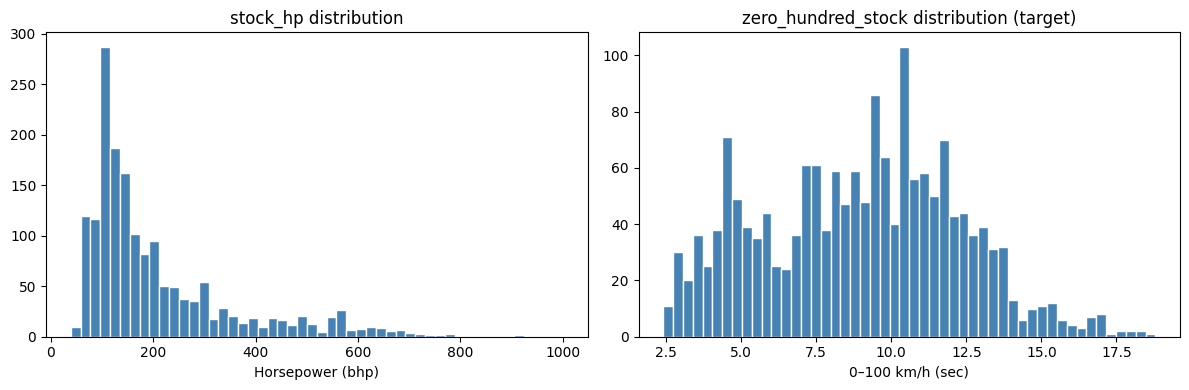

In [16]:
# Visualise the hp distribution to make the outlier decision visible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['stock_hp'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('stock_hp distribution')
axes[0].set_xlabel('Horsepower (bhp)')

axes[1].hist(df['zero_hundred_stock'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('zero_hundred_stock distribution (target)')
axes[1].set_xlabel('0–100 km/h (sec)')

plt.tight_layout()
plt.savefig('../docs/distributions_after_cleaning.png', dpi=120)
plt.show()

---
## Step 8 - Final audit

Check that the cleaned dataset has no remaining nulls in the columns we use for modelling,
and that the shape and value ranges look sensible.

In [17]:
print(f"Final shape: {df.shape}")
print(f"\nRemaining nulls:")
remaining = df.isnull().sum()
print(remaining[remaining > 0].to_string() if remaining.sum() > 0 else "  None — dataset is clean.")
print(f"\nengine_type distribution (no 'Unknown' should remain):")
print(df['engine_type'].value_counts().to_string())

Final shape: (1696, 18)

Remaining nulls:
  None — dataset is clean.

engine_type distribution (no 'Unknown' should remain):
engine_type
Naturally Aspirated    938
Diesel                 295
Turbocharged           202
EV                     199
Hybrid                  62


In [18]:
# Summary of what changed
print("=== CLEANING SUMMARY ===")
print(f"  Rows:    {len(cars)} → {len(df)}  (dropped {len(cars)-len(df)}, {(len(cars)-len(df))/len(cars)*100:.1f}%)")
print(f"  Columns: {cars.shape[1]} → {df.shape[1]}  (dropped {cars.shape[1]-df.shape[1]})")
print(f"  Nulls:   {cars.isnull().sum().sum()} → {df.isnull().sum().sum()}")

=== CLEANING SUMMARY ===
  Rows:    2150 → 1696  (dropped 454, 21.1%)
  Columns: 23 → 18  (dropped 5)
  Nulls:   10191 → 0


---
## Step 9 - Save

The clean dataset goes to `data/interim/` - not `data/raw/` (we never overwrite raw data)
and not `data/final/` (feature engineering still to come).
`interim` is the staging area between raw and ready.

In [19]:
df.to_csv('../data/interim/cars_clean.csv', index=False)
print(f"Saved → data/interim/cars_clean.csv  ({len(df)} rows × {df.shape[1]} cols)")

Saved → data/interim/cars_clean.csv  (1696 rows × 18 cols)


---
## Step 10 - Re-run the baseline model on clean data

Same model, same features, same evaluation as notebook `02_baseline_dirty`.
The only difference is the data going in.
Any improvement in CV MAE is attributable purely to cleaning decisions.

In [20]:
FEATURES = ['stock_hp', 'weight_kg', 'displacement_cc', 'cylinders',
            'drivetrain', 'engine_type', 'fuel_type']
TARGET = 'zero_hundred_stock'

df_model = df[FEATURES + [TARGET]].copy()

# Same crude encoding as the dirty baseline — fair comparison
for col in ['drivetrain', 'engine_type', 'fuel_type']:
    df_model[col] = pd.Categorical(df_model[col]).codes

df_model = df_model.fillna(df_model.median(numeric_only=True))

X = df_model[FEATURES].values
y = df_model[TARGET].values

model = LinearRegression()
model.fit(X, y)
y_pred  = model.predict(X)
mae     = mean_absolute_error(y, y_pred)
r2      = r2_score(y, y_pred)
cv_mae  = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error').mean()

import json
with open('../data/interim/baseline_scores.json') as _f:
    _b = json.load(_f)              # written by notebook 02 — never goes stale
DIRTY_CV_MAE = _b['dirty_cv_mae']
DIRTY_R2     = _b['dirty_r2']

print("=" * 40)
print(f"{'':20} {'Dirty':>8} {'Clean':>8} {'Δ':>8}")
print("-" * 40)
print(f"{'CV MAE (sec)':20} {DIRTY_CV_MAE:>8.3f} {cv_mae:>8.3f} {cv_mae - DIRTY_CV_MAE:>+8.3f}")
print(f"{'R²':20} {DIRTY_R2:>8.3f} {r2:>8.3f} {r2 - DIRTY_R2:>+8.3f}")
print("=" * 40)
print()
print("→ Improvement from cleaning alone, before any feature engineering.")

                        Dirty    Clean        Δ
----------------------------------------
CV MAE (sec)            1.436    1.425   -0.011
R²                      0.724    0.730   +0.005

→ Improvement from cleaning alone, before any feature engineering.


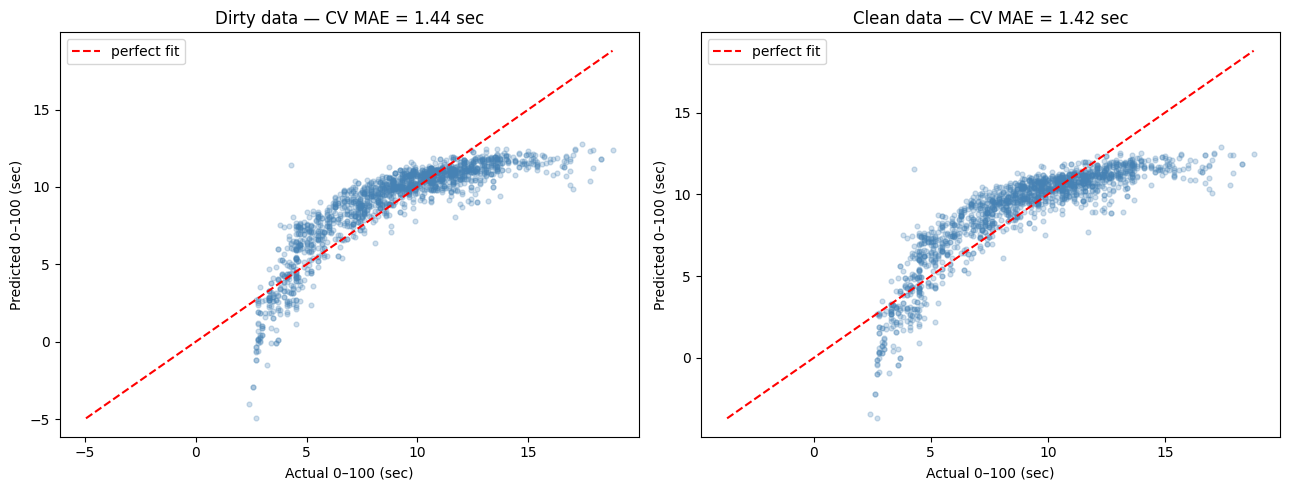

In [21]:
# Side-by-side scatter: dirty vs clean
# Load dirty predictions for comparison
cars_dirty = pd.read_csv('../data/raw/cars_raw.csv')
df_dirty   = cars_dirty[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()
for col in ['drivetrain', 'engine_type', 'fuel_type']:
    df_dirty[col] = pd.Categorical(df_dirty[col]).codes
df_dirty = df_dirty.fillna(df_dirty.median(numeric_only=True))
X_d, y_d = df_dirty[FEATURES].values, df_dirty[TARGET].values
m_dirty   = LinearRegression().fit(X_d, y_d)
yp_dirty  = m_dirty.predict(X_d)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, actual, predicted, title, mae_val in [
    (axes[0], y_d, yp_dirty, f'Dirty data — CV MAE = {DIRTY_CV_MAE:.2f} sec', DIRTY_CV_MAE),
    (axes[1], y,   y_pred,   f'Clean data — CV MAE = {cv_mae:.2f} sec',       cv_mae),
]:
    ax.scatter(actual, predicted, alpha=0.25, s=12, color='steelblue')
    lims = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='perfect fit')
    ax.set_xlabel('Actual 0–100 (sec)')
    ax.set_ylabel('Predicted 0–100 (sec)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('../docs/dirty_vs_clean.png', dpi=120)
plt.show()

---
## Summary

See the comparison table in Step 10 for the exact dirty-vs-clean numbers on the current
dataset (they are computed live, so they update automatically whenever the data changes).

Result: cleaning fixed every null value and removed noise, but the linear model's
score barely moved. This is expected and important - cleaning made the data *correct*, but it
did not change the *representation* of the problem. The model is still trying to fit a
power-law relationship (`t ∝ (weight/hp)^0.6`) with a straight line.

Next: `04_features` - engineer `power_to_weight`, `is_turbocharged`, `is_awd` and other
derived features. This is where we expect the biggest improvement, because it directly
addresses the non-linear relationship visible in the baseline scatter plot.